In [1]:
import os
import numpy as np

import rasterio as rio
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
import japanize_matplotlib

In [3]:
# 画像パスの設定
S1a_INPUT = '/workspace/data/S1A_IW_GRDH_1SDV_20190924.tif'
S1b_INPUT = '/workspace/data/S1B_IW_GRDH_1SDV_20191012.tif'

下準備（画像の準備）

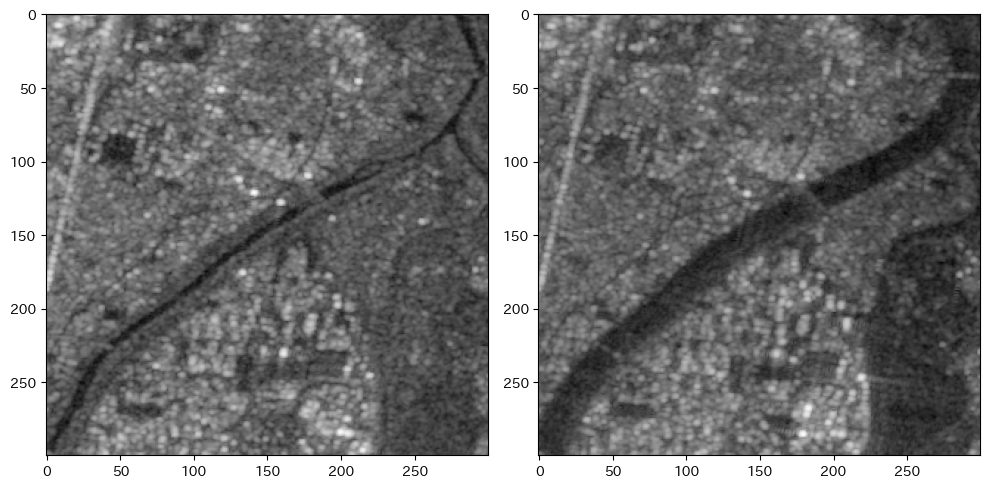

In [94]:
# 出力ディレクトリを作成
output_dir = '/workspace/output/'

# 1. before_dBを[80:450, 550:700]で切り抜く
with rio.open(S1a_INPUT) as src:
    profile = src.profile
    before_img = src.read(1)
    before_img = np.where(before_img == 0, np.nan, before_img)
    before_dB = 10 * np.log10(before_img)
    before_dB_clipped = before_dB[600:900, 310:610]
    
    # 新しい変換を計算
    new_transform = src.transform * rio.Affine.translation(310, 600)

# 2. 切り抜いたbefore_dBをworkspace/output/に保存
output_meta = profile.copy()
output_meta.update({
    "driver": "GTiff",
    "height": before_dB_clipped.shape[0],
    "width": before_dB_clipped.shape[1],
    "transform": new_transform,
})

output_before_dB = os.path.join(output_dir, 'before_dB_clipped.tif')
with rio.open(output_before_dB, "w", **output_meta) as dest:
    dest.write(before_dB_clipped, 1)

# 3. outputに保存したbefore_dBを読み込み
with rio.open(output_before_dB) as src:
    before_dB_clipped = src.read(1)
    before_dB_meta = src.meta

# 4. S1b_INPUTとDEM_INPUTを読み込み、S1b_INPUTを変換、DEMをリサンプリング
with rio.open(S1b_INPUT) as src:
    after_img = src.read(1)
    after_img = np.where(after_img == 0, np.nan, after_img)
    after_dB = 10 * np.log10(after_img)

# 5. before_dBを基に上2つを切り抜き
def clip_image(img, reference_transform, reference_shape, src_transform):
    src_bounds = rio.transform.array_bounds(img.shape[0], img.shape[1], src_transform)
    dst_bounds = rio.transform.array_bounds(reference_shape[0], reference_shape[1], reference_transform)
    
    window = rio.windows.from_bounds(*dst_bounds, transform=src_transform)
    return img[int(window.row_off):int(window.row_off+window.height), 
               int(window.col_off):int(window.col_off+window.width)]

with rio.open(S1b_INPUT) as src:
    after_dB_clipped = clip_image(after_dB, new_transform, before_dB_clipped.shape, src.transform)

# クリップされた画像を保存
output_after_dB = os.path.join(output_dir, 'after_dB_clipped.tif')
with rio.open(output_after_dB, "w", **output_meta) as dest:
    dest.write(after_dB_clipped, 1)

# 6. 3つを可視化
plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(before_dB_clipped, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(after_dB_clipped, cmap='gray')
plt.tight_layout()

plt.savefig('/workspace/output/koriyama_aoi.png')
plt.show()

In [136]:
# マルチルック処理
def apply_multilook(image, n_look):
    reshaped_data = image.reshape((image.shape[0] // n_look, n_look, image.shape[1] // n_look, n_look))
    return reshaped_data.mean(axis=(1, 3))

# L+とL-タイルの生成
def create_tiles(image, tile_size):
    height, width = image.shape
    
    # タイルサイズの倍数に画像サイズを調整
    new_height = (height // tile_size) * tile_size
    new_width = (width // tile_size) * tile_size
    image = image[:new_height, :new_width]

    # 画像のサイズとタイルのサイズから縦横のタイル数を設定
    n_rows = new_height // tile_size
    n_cols = new_width // tile_size

    # L+とL-のタイルを生成
    l_plus = []
    l_plus_positions = []
    l_minus = []
    l_minus_positions = []
    for i in range(n_rows):
        for j in range(n_cols):
            y_start = i * tile_size
            y_end = (i + 1) * tile_size
            x_start = j * tile_size
            x_end = (j + 1) * tile_size
            l_plus_tile = image[y_start:y_end, x_start:x_end]

            # 欠損値がないL+タイルのみを処理
            if not np.isnan(l_plus_tile).any():
                l_plus.append(l_plus_tile)
                l_plus_positions.append((y_start, y_end, x_start, x_end))

                l_minus_tiles = []
                l_minus_tiles_positions = []
                half_tile_size = tile_size // 2

                for y in range(0, tile_size, half_tile_size):
                    for x in range(0, tile_size, half_tile_size):
                        l_minus_tile = l_plus_tile[y:y+half_tile_size, x:x+half_tile_size]
                        l_minus_tiles.append(l_minus_tile)
                        l_minus_tiles_positions.append((y_start + y, y_start + y + half_tile_size, x_start + x, x_start + x + half_tile_size))
                
                l_minus.append(l_minus_tiles)
                l_minus_positions.append(l_minus_tiles_positions)

    return l_plus, l_plus_positions, l_minus, l_minus_positions

# L+タイルとL-タイルの統計情報から変動係数を算出
def calculate_coefficient_of_variation(l_plus, l_minus):
    coefficients_of_variation = []

    for i, l_plus_tile in enumerate(l_plus):
        l_minus_tiles = l_minus[i]
        l_minus_means = [np.mean(tile) for tile in l_minus_tiles]
        mean_std = np.std(l_minus_means)
        l_plus_mean = np.mean(l_plus_tile)
        coefficient_of_variation = mean_std / l_plus_mean
        coefficients_of_variation.append(coefficient_of_variation)

    return coefficients_of_variation

# 変動係数のリストから指定したパーセンタイルを超えるインデックスと値を抽出
def extract_top_percentile(coefficients_of_variation, percentile):
    threshold = np.percentile(coefficients_of_variation, percentile)
    
    top_coefficients = []
    for i, cv in enumerate(coefficients_of_variation):
        if cv > threshold:
            top_coefficients.append((i, cv))

    return top_coefficients

# 全体のL+タイルの平均値よりも低い平均値を持つL+タイルを抽出
def check_and_return_l_plus_below_average(l_plus, top_coefficients):
    all_l_plus_means = [np.nanmean(tile) for tile in l_plus]
    average_of_all_l_plus = np.nanmean(all_l_plus_means)

    l_plus_below_average = []
    indices_below_average = []
    for i, _ in top_coefficients:
        top_l_plus_mean = np.nanmean(l_plus[i])
        if top_l_plus_mean < average_of_all_l_plus:
            l_plus_below_average.append(l_plus[i])
            indices_below_average.append(i)

    return l_plus_below_average, indices_below_average

# 変動係数を基に抽出したタイルを可視化
def visualize_and_save_top_tiles(before_image, before_l_plus_positions, before_indices_below_average, 
                                 after_image, after_l_plus_positions, after_indices_below_average):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 10))

    # Before image
    ax1.imshow(before_image, cmap='gray')
    for i in before_indices_below_average:
        y_start, y_end, x_start, x_end = before_l_plus_positions[i]
        rect = plt.Rectangle((x_start, y_start), x_end - x_start, y_end - y_start, 
                             edgecolor='red', facecolor='none', linewidth=2)
        ax1.add_patch(rect)

    # After image
    ax2.imshow(after_image, cmap='gray')
    for i in after_indices_below_average:
        y_start, y_end, x_start, x_end = after_l_plus_positions[i]
        rect = plt.Rectangle((x_start, y_start), x_end - x_start, y_end - y_start, 
                             edgecolor='red', facecolor='none', linewidth=2)
        ax2.add_patch(rect)

    plt.tight_layout()
    
    # Save the figure
    plt.savefig('/workspace/output/before_after_l_tile.png', dpi=300, bbox_inches='tight')
    plt.show()

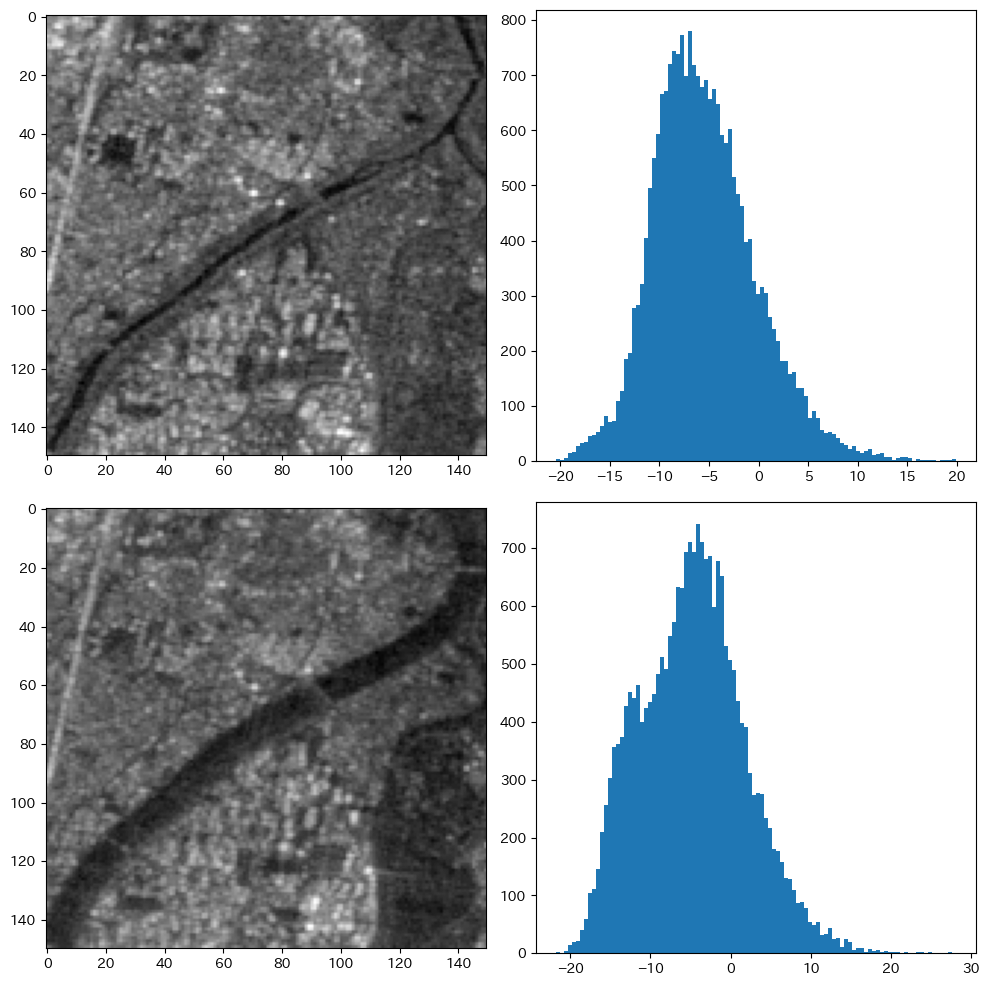

In [137]:
n_look = 2
before_multilooked = apply_multilook(before_dB_clipped, n_look)
after_multilooked = apply_multilook(after_dB_clipped, n_look)

plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.imshow(before_multilooked, cmap='gray')
plt.subplot(2, 2, 2)
plt.hist(before_multilooked.flatten(), bins=100)
plt.subplot(2, 2, 3)
plt.imshow(after_multilooked, cmap='gray')
plt.subplot(2, 2, 4)
plt.hist(after_multilooked.flatten(), bins=100)
plt.tight_layout()

plt.savefig('/workspace/output/koriyama_multilooked.png')
plt.show()

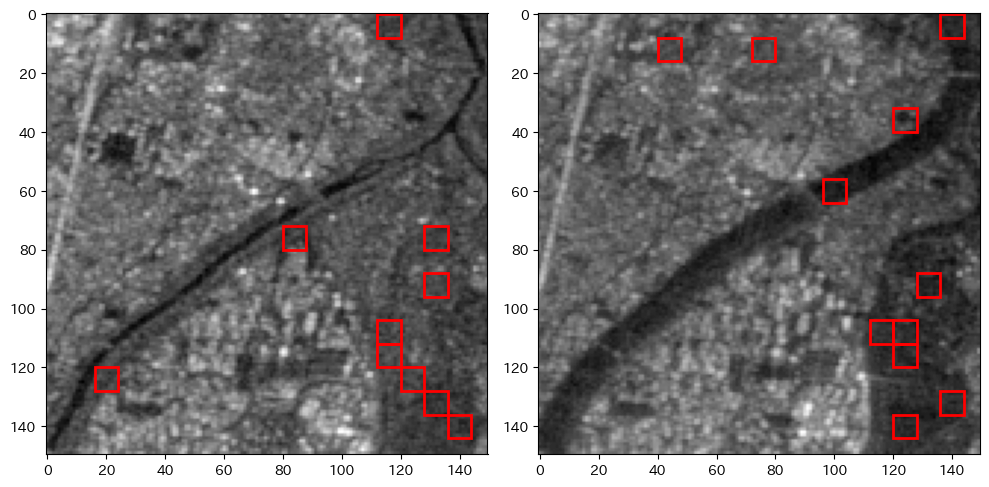

In [138]:
# 局所的閾値法の適用
before_l_plus, before_l_plus_positions, before_l_minus, before_l_minus_positions = create_tiles(before_multilooked, tile_size=8)
before_coefficients_of_variation = calculate_coefficient_of_variation(before_l_plus, before_l_minus)
before_top_coefficients = extract_top_percentile(before_coefficients_of_variation, percentile=90)
before_l_plus_below_average, before_indices_below_average  = check_and_return_l_plus_below_average(before_l_plus, before_top_coefficients)

after_l_plus, after_l_plus_positions, after_l_minus, after_l_minus_positions = create_tiles(after_multilooked, tile_size=8)
after_coefficients_of_variation = calculate_coefficient_of_variation(after_l_plus, after_l_minus)
after_top_coefficients = extract_top_percentile(after_coefficients_of_variation, percentile=80)
after_l_plus_below_average, after_indices_below_average  = check_and_return_l_plus_below_average(after_l_plus, after_top_coefficients)

visualize_and_save_top_tiles(before_multilooked, before_l_plus_positions, before_indices_below_average, 
                             after_multilooked, after_l_plus_positions, after_indices_below_average)

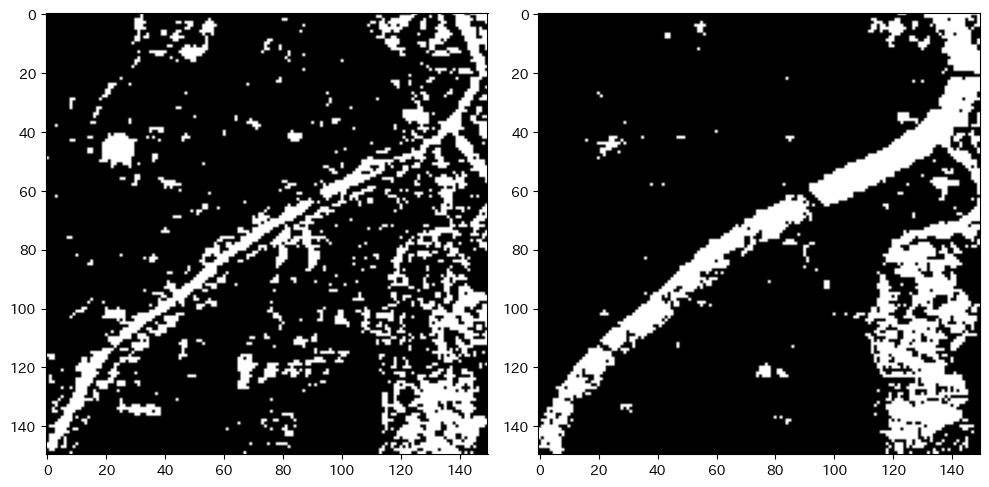

In [139]:
# 閾値の算出
before_threshold = np.nanmean(before_l_plus_below_average)
after_threshold = np.nanmean(after_l_plus_below_average)

# 2値化画像の作成
before_binalized = np.where(before_multilooked < before_threshold, 1, 0)
after_binalized = np.where(after_multilooked < after_threshold, 1, 0)

# 水域マスクの可視化
plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(before_binalized, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(after_binalized, cmap='gray')
plt.tight_layout()

plt.savefig('/workspace/output/koriyama_water_delineation.png')
plt.show()   

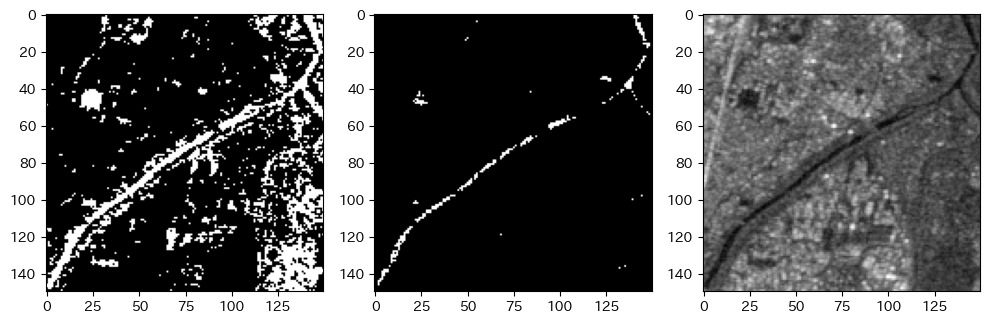

In [144]:
# 災害前のマスク画像に局所的閾値法を適用
before_binalized_multilooked = np.where(before_binalized, before_multilooked, np.nan)
before_l_plus, before_l_plus_positions, before_l_minus, before_l_minus_positions = create_tiles(before_binalized_multilooked, tile_size=4)
before_coefficients_of_variation = calculate_coefficient_of_variation(before_l_plus, before_l_minus)
before_top_coefficients = extract_top_percentile(before_coefficients_of_variation, percentile=80)
before_l_plus_below_average, before_indices_below_average  = check_and_return_l_plus_below_average(before_l_plus, before_top_coefficients)
before_rethreshold = np.nanmean(before_l_plus_below_average)
before_rebinalized = np.where(before_binalized_multilooked < before_rethreshold, 1, 0)

# 可視化 
plt.figure(figsize=(10, 10))
plt.subplot(1, 3, 1)
plt.imshow(before_binalized, cmap='gray')
plt.subplot(1, 3, 2)
plt.imshow(before_rebinalized, cmap='gray')
plt.subplot(1, 3, 3)
plt.imshow(before_multilooked, cmap='gray')
plt.tight_layout()

plt.savefig('/workspace/output/koriyama_binalized_rebinalized.png')
plt.show()

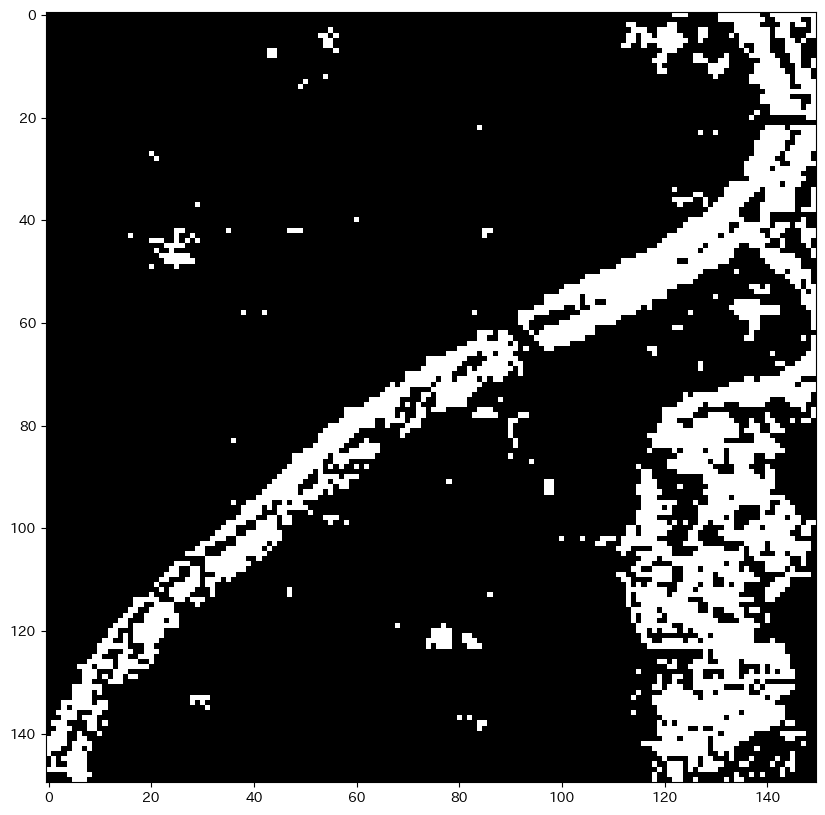

In [147]:
# 浸水域の抽出
diff = after_binalized - before_rebinalized
flood_delineation = np.where(diff == 0, 0, 1)

# 可視化
plt.figure(figsize=(10, 10))
plt.imshow(flood_delineation, cmap='gray')
plt.savefig('/workspace/output/koriyama_flood_delineation.png')
plt.show()